### Surface Runoff Susceptibility in Nisqually River Watershed Data Download

### Study Area

In [1]:
# Import packages for working with files and folders
import os
import pathlib

# Import package for working with geospatial data
import geopandas as gpd

# Import package for working with tabular data
import pandas as pd

# Import libaray for plotting
import matplotlib.pyplot as plt

# Import library for working with scientific computation
import numpy as np

# Import library for making interactive plots with vector/tabular data
import hvplot.pandas 

# Import library for making interactive plot
import holoviews as hv

# Import for working with zip files
import zipfile

# Import for creating file folders
from pathlib import Path

# Access NASA earth data (topography)
import earthaccess

# File pattern for data
from glob import glob

# Import libraries for working with raster data
import rioxarray as rxr
import xarray as xr
import xrspatial

# Import library plotting raster data
import matplotlib.pyplot as plt

# Import library for merging raster data
from rioxarray.merge import merge_arrays

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import rioxarray as rxr

# Read elevation raster
from pysheds.grid import Grid


In [2]:
# Create base project directory
project_dir = os.path.join(
    pathlib.Path.home(),
    "Documents",
    "education",
    "earth-data-analytics",
    "spring-2026-data",
    "surface-runoff-susceptibility-model"
)

# Define all directories in one dictionary
dirs = {
    "project": project_dir,
    "wbd": os.path.join(project_dir, "watershed-boundary-dataset"),
    "topography": os.path.join(project_dir, "topography"),
    "soils": os.path.join(project_dir, "soils"),
    "climate": os.path.join(project_dir, "climate"),
    "impervious": os.path.join(project_dir, "nlcd-impervious"),
}

# Create all directories
for path in dirs.values():
    os.makedirs(path, exist_ok=True)

# Assign individual dir variables
wbd_dir = dirs["wbd"]
topography_dir = dirs["topography"]
soils_dir = dirs["soils"]
climate_dir = dirs["climate"]
impervious_dir = dirs["impervious"]

# Check one of them
print(wbd_dir)
print(os.path.exists(wbd_dir))

C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\watershed-boundary-dataset
True


In [3]:
# Intialize path to DEM raster for pysheds use later
dem_5070_path = os.path.join(topography_dir, "nisqually_dem_5070.tif")

# Conditionally read the DEM raster if it exists, otherwise raise an error
if not os.path.exists(dem_5070_path):
    raise FileNotFoundError(f"DEM not found: {dem_5070_path}")

# Read the DEM raster using pysheds to create a grid object for hydrological analysis
grid = Grid.from_raster(dem_5070_path)
print("Grid ready")

Grid ready


In [4]:
# Path to the downloaded zip file
zip_path = os.path.join(wbd_dir, "WBD_17_HU2_GPKG.zip")

# Extracted directory path
extract_dir = os.path.join(wbd_dir, "extracted")
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Path to GeoPackage (after unzip)
wbd_gpkg_path = os.path.join(extract_dir, "WBD_17_HU2_GPKG.gpkg")

# Read HUC8 layer
wbd_gdf = gpd.read_file(wbd_gpkg_path, layer="WBDHU8")

# Check the first few rows
print(wbd_gdf.head())

                                    tnmid  \
0  {3DB62677-1E95-4C7F-A328-2DF39761B05D}   
1  {C19C3336-0531-43B8-8DAC-569C87D4E46C}   
2  {1F9A8978-7AF6-4B64-83A8-6296AF7194FD}   
3  {31964435-132E-4924-ADF4-5D732EBE86D9}   
4  {E601469F-456B-46E2-9AD8-49049D17B6C5}   

                             metasourceid                    sourcedatadesc  \
0  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
1  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
2  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
3  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   
4  {511D2AC8-11BA-45FC-AB98-F69D693D4C44}  Watershed Boundary Dataset (WBD)   

                                    sourceoriginator sourcefeatureid  \
0  Natural Resources and Conservation Service and...            None   
1  Natural Resources and Conservation Service and...            None   
2  Natural Resources and Conservation 

In [5]:
# Check the columns
print(wbd_gdf.columns)

Index(['tnmid', 'metasourceid', 'sourcedatadesc', 'sourceoriginator',
       'sourcefeatureid', 'loaddate', 'referencegnis_ids', 'areaacres',
       'areasqkm', 'states', 'huc8', 'name', 'shape_Length', 'shape_Area',
       'geometry'],
      dtype='object')


In [6]:
# Check the geometry type
wbd_gdf.head()

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
0,{3DB62677-1E95-4C7F-A328-2DF39761B05D},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,455018.41,1841.40,OR,17090007,Middle Willamette,NaN,NaN,"POLYGON ((-123.04359 45.38033, -123.04345 45.3..."
1,{C19C3336-0531-43B8-8DAC-569C87D4E46C},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1136527,857035.12,3468.30,OR,17090004,Mckenzie,NaN,NaN,"POLYGON ((-122.02273 44.50785, -122.02237 44.5..."
2,{1F9A8978-7AF6-4B64-83A8-6296AF7194FD},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1158060,1198333.82,4849.49,OR,17090003,Upper Willamette,NaN,NaN,"POLYGON ((-123.38229 44.90266, -123.38196 44.9..."
3,{31964435-132E-4924-ADF4-5D732EBE86D9},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,1150077,666390.78,2696.79,OR,17090006,South Santiam,NaN,NaN,"POLYGON ((-122.66308 44.76978, -122.66266 44.7..."
4,{E601469F-456B-46E2-9AD8-49049D17B6C5},{511D2AC8-11BA-45FC-AB98-F69D693D4C44},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,2024-08-16 10:24:20,391131,571545.15,2312.96,WA,17010307,Lower Spokane,NaN,NaN,"POLYGON ((-117.9992 48.12883, -117.99877 48.12..."


In [7]:
# Check for the Nisqually watershed
wbd_gdf[wbd_gdf["name"].str.contains("Nisqually", case=False)]

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc8,name,shape_Length,shape_Area,geometry
227,{AB20B6D1-23E0-4AEB-A1EC-55722FB6D0DE},{A9DB8B60-5A4A-4FFC-8BE7-FA64FC77FE78},Pierce 2020,"Pierce County Washington, Washington State Dep...",None,2024-10-30 13:39:19,1511938,492844.38,1994.47,WA,17110015,Nisqually,NaN,NaN,"MULTIPOLYGON (((-122.68186 47.09905, -122.6813..."


In [8]:
# Subset to just the Nisqually watershed
nisqually_gdf = wbd_gdf[wbd_gdf["huc8"] == "17110015"]

In [9]:
# Check the name of the watershed
print(nisqually_gdf["name"])

227    Nisqually
Name: name, dtype: object


<Axes: >

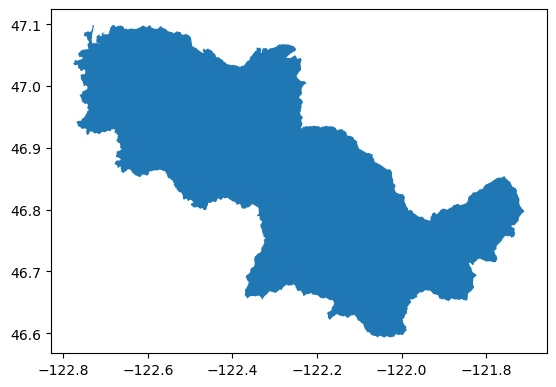

In [10]:
# Plot to see that it worked
nisqually_gdf.plot()

In [11]:
# Plot the results with web tile images
nisqually_gdf_plot = nisqually_gdf.hvplot(
    geo=True, tiles='EsriImagery',
    fill_color=None, line_color='white',
    title='Nisqually Watershed (HUC8)',
    frame_width=500,
    xlabel="Longitude",
    ylabel="Latitude")

# Display the plot with esri imagery
nisqually_gdf_plot

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

### SRTM NASA DEM data downlaod (30-m resolution)


In [12]:
# Set up Earth Access
earthaccess.login()

In [13]:
# Search for SRTM data
datasets = earthaccess.search_datasets(keyword = "SRTM DEM")
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
AST14DEM ASTER Digital Elevation Model V004
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
NASADEM_NC NASA

In [14]:
# File pattern for data
nisqually_gdf_srtm_pattern = os.path.join(topography_dir, '*.hgt.zip')

# Study area for topo data
nisqually_gdf_elev_bounds = tuple(nisqually_gdf.total_bounds)

# Add buffer
buffer = 0.025
nisqually_xmin, nisqually_ymin, nisqually_xmax, nisqually_ymax = nisqually_gdf_elev_bounds
nisqually_elev_bounds_buffer = (nisqually_xmin - buffer,
                                 nisqually_ymin - buffer,
                                 nisqually_xmax + buffer,
                                 nisqually_ymax + buffer)

# Look at the results
srtm_files = glob(nisqually_gdf_srtm_pattern)

if not srtm_files:

    # Search for data
    nisqually_gdf_srtm_search = earthaccess.search_data(
        short_name = 'SRTMGL3',
        bounding_box = nisqually_elev_bounds_buffer
    )

    # Download data
    nisqually_gdf_srtm_results = earthaccess.download(
        nisqually_gdf_srtm_search,
        topography_dir
    )

# Add text if files already downloaded
else:
    print("SRTM files already downloaded")
    nisqually_gdf_srtm_results = srtm_files

SRTM files already downloaded


In [15]:
# Check it out
nisqually_gdf_srtm_results

['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N46W122.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N46W123.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N47W122.SRTMGL3.hgt.zip',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\topography\\N47W123.SRTMGL3.hgt.zip']

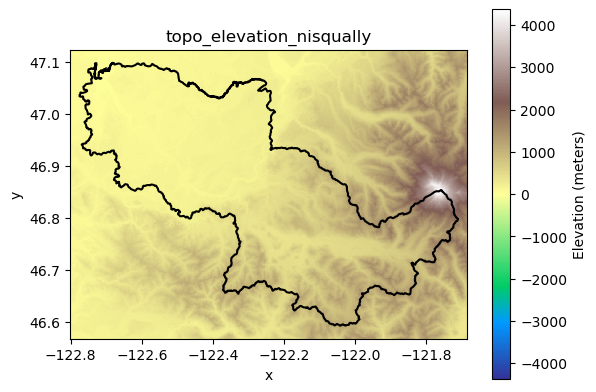

In [16]:
nisqually_gdf_srtm_da_list = []
for srtm_path in glob(nisqually_gdf_srtm_pattern):
    tile_da = rxr.open_rasterio(srtm_path, mask_and_scale = True).squeeze()
    srtm_cropped_da = tile_da.rio.clip_box(*nisqually_elev_bounds_buffer)
    nisqually_gdf_srtm_da_list.append(srtm_cropped_da)

# Merge 
nisqually_srtm_da = merge_arrays(nisqually_gdf_srtm_da_list)

nisqually_srtm_da.plot(cmap='terrain', cbar_kwargs={'label': 'Elevation (meters)'})

nisqually_gdf.boundary.plot(ax = plt.gca(), color='black')

# Add title
plt.title("topo_elevation_nisqually")

# Check it out
plt.show()

In [17]:
# Save the merged raster to a new file
# Create a copy of the data array to modify for saving
nisqually_save_da = nisqually_srtm_da.copy()

# Remove any existing _FillValue attribute and encoding to avoid issues when writing the raster
nisqually_save_da.attrs.pop("_FillValue", None)

# Remove any existing _FillValue from encoding and set the nodata value to -9999
nisqually_save_da.encoding.pop("_FillValue", None)
nisqually_save_da = nisqually_save_da.rio.write_nodata(-9999)

# Create the path for the new raster file
dem_path = os.path.join(topography_dir, "nisqually_dem.tif")

# Save the raster to a new file
nisqually_save_da.rio.to_raster(dem_path)

# Check that the file was saved correctly
print(dem_path)
print(os.path.exists(dem_path))


C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_dem.tif
True


In [18]:
# Check the min and max values
print(nisqually_srtm_da.min().values)
print(nisqually_srtm_da.max().values)

-4.0
4371.0


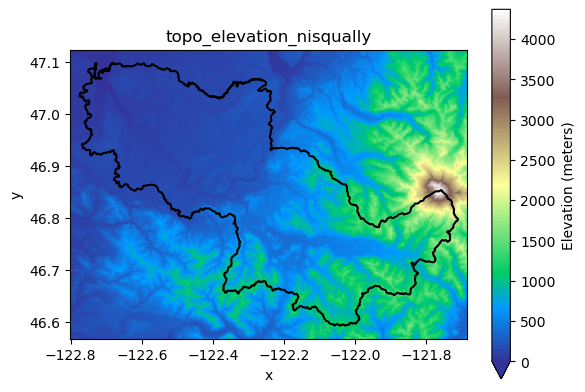

In [19]:
# Plot with limits for better visualization
nisqually_srtm_da.plot(
    cmap="terrain",
    vmin=0,
    vmax=float(nisqually_srtm_da.max()),
    cbar_kwargs={"label": "Elevation (meters)"}
)

# Add watershed boundary
nisqually_gdf.boundary.plot(ax=plt.gca(), color="black")
plt.title("topo_elevation_nisqually")
plt.show()

### NLCD Impervious Surface

In [20]:
# Path to zip file
zip_path = os.path.join(impervious_dir, "NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip")

# Unzip to the same directory
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(impervious_dir)

# Check the extracted files
print("Unzipped successfully")

Unzipped successfully


In [21]:
# List the files in the impervious directory to see the extracted contents
for file in os.listdir(impervious_dir):
    print(file)

Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.tiff
Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.tiff.aux.xml
Annual_NLCD_FctImp_2024_CU_C1V1_84d4ec6e-782d-4ca1-985c-369c3d869faf.xml
extracted
nisqually_impervious_5070.tif
NLCD Fractional Impervious Surface.gif
NLCD_84d4ec6e-782d-4ca1-985c-369c3d869faf.zip


In [22]:
# Find the tif
tif_files = [
    f for f in os.listdir(impervious_dir)
    if f.lower().endswith((".tif", ".tiff"))
]

# Check the tif files found
impervious_path = os.path.join(impervious_dir, tif_files[0])

# Open it
impervious_da = rxr.open_rasterio(impervious_path, masked=True).squeeze()

# Check the dataarray
print(impervious_da)

<xarray.DataArray (y: 5801, x: 7270)> Size: 169MB
[42173270 values with dtype=float32]
Coordinates:
  * y            (y) float64 46kB 3.01e+06 3.01e+06 ... 2.836e+06 2.836e+06
  * x            (x) float64 58kB -2.087e+06 -2.087e+06 ... -1.869e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        100
    STATISTICS_MEAN:           3.2224650619265
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         12.153386299596
    STATISTICS_VALID_PERCENT:  63.85
    scale_factor:              1.0
    add_offset:                0.0


In [23]:
# Check CRS, bounds, and resolution
print(impervious_da.rio.crs)
print(impervious_da.rio.bounds())
print(impervious_da.rio.resolution())

PROJCS["AEA        WGS84",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
(-2087175.0, 2835735.0, -1869075.0, 3009765.0)
(30.0, -30.0)


In [24]:
impervious_5070 = impervious_da.rio.reproject("EPSG:5070")

In [25]:
nisqually_gdf_5070 = nisqually_gdf.to_crs("EPSG:5070")

impervious_clip = impervious_5070.rio.clip(
    nisqually_gdf_5070.geometry,
    nisqually_gdf_5070.crs,
    drop=True
)

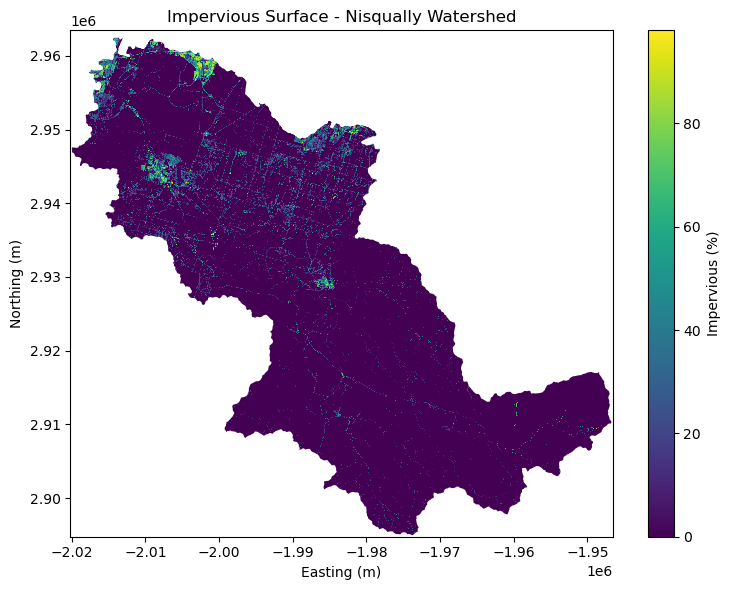

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

impervious_clip.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Impervious (%)"}
)

nisqually_gdf_5070.boundary.plot(
    ax=ax,
    edgecolor="white",
    linewidth=1.5
)

ax.set_title("Impervious Surface - Nisqually Watershed")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

In [27]:
def clean_and_save(da, path):
    """Function to clean the data array and save it to a raster file.
    
    Args:
    da (xarray.DataArray): The data array to clean and save
    path (str): The file path to save the raster to
    
    Returns:
    None
    """
    save_da = da.copy()
    save_da.attrs.pop("_FillValue", None)
    save_da.encoding.pop("_FillValue", None)
    save_da = save_da.astype("float32")
    save_da = save_da.fillna(-9999)
    save_da = save_da.rio.write_nodata(-9999)
    save_da.rio.to_raster(path, dtype="float32")
    print(f"Saved: {path}")

In [28]:
impervious_5070_path = os.path.join(
    impervious_dir,
    "nisqually_impervious_5070.tif"
)

clean_and_save(impervious_clip, impervious_5070_path)

Saved: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\nlcd-impervious\nisqually_impervious_5070.tif


### MACA Climate Data

In [29]:
# Create function to convert longitude values
def convert_longitude(longitude):

    """
    Function to convert longitude

    Args:
    longitude:

    Returns:Function to convert longitude
    """
    
    return (longitude - 360) if longitude > 180 else longitude 

In [30]:
# Create directory for file
climate_pattern = os.path.join(climate_dir, '*.nc')
climate_pattern

'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\*.nc'

In [31]:
# Define some parameters
site_name = "Nisqually"
site_gdf = nisqually_gdf
date_range = "2041_2045"
model = "CCSM4"
rcp_value = "rcp45"
climate_var = "pr"

In [32]:
# Create a maca path
climate_path = os.path.join(
    climate_dir,
    f"maca_{model}_{site_name}_{date_range}_CONUS_daily.nc"
)

In [33]:
# Construct the URL where the climate data lives
climate_url = (
    "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
    "/MACAV2"
    f"/{model}"
    "/macav2metdata"
    f"_{climate_var}"
    f"_{model}_r6i1p1"
    f"_{rcp_value}"
    f"_{date_range}_CONUS"
    "_daily.nc"
)

In [34]:
# Check out the url
climate_url

'http://thredds.northwestknowledge.net:8080/thredds/dodsC/MACAV2/CCSM4/macav2metdata_pr_CCSM4_r6i1p1_rcp45_2041_2045_CONUS_daily.nc'

In [35]:
# Open the dataset using xarray
ds = xr.open_dataset(climate_url)
print(ds.data_vars)

Data variables:
    precipitation  (time, lat, lon) float32 6GB ...


In [36]:
# Check if the variable is "pr" or "precipitation" and assign to climate_da
climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]
print(climate_da)

<xarray.DataArray 'precipitation' (time: 1826, lat: 585, lon: 1386)> Size: 6GB
[1480539060 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 15kB 2041-01-01 2041-01-02 ... 2045-12-31
  * lat      (lat) float64 5kB 25.06 25.1 25.15 25.19 ... 49.27 49.31 49.35 49.4
  * lon      (lon) float64 11kB 235.2 235.3 235.3 235.4 ... 292.9 292.9 292.9
Attributes:
    long_name:      Precipitation
    units:          mm
    grid_mapping:   crs
    standard_name:  precipitation
    cell_methods:   time: sum(interval: 24 hours)
    comments:       Total daily precipitation at surface; includes both liqui...
    _ChunkSizes:    [162  51 123]


In [37]:
# Check remote point values to make sure it looks right
pt_raw = climate_da.sel(lat=46.85, lon=237.8, method="nearest")
print("Remote raw point min/max:", float(pt_raw.min()), float(pt_raw.max()))

Remote raw point min/max: 0.0 92.08182525634766


In [38]:
# Convert longitude values to the range [-180, 180]
climate_da = climate_da.assign_coords(
    lon=(((climate_da.lon + 180) % 360) - 180).data
).sortby("lon")

In [39]:
# Check the converted point values to make sure it looks right
pt_conv = climate_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote converted point min/max:", float(pt_conv.min()), float(pt_conv.max()))

Remote converted point min/max: 0.0 92.08182525634766


In [40]:
# Match the CRS of the climate data to the watershed boundary
nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")

# Create a bounding box for the watershed
minx, miny, maxx, maxy = nisqually_4326.total_bounds
print(minx, miny, maxx, maxy)

-122.77620911906662 46.59305184666876 -121.71018763313434 47.09906060599487


In [41]:
# Crop the climate data to the bounding box of the watershed
climate_da_cropped = climate_da.sel(
    lon=slice(minx, maxx),
    lat=slice(miny, maxy)
)

In [42]:
# Check the cropped point values to make sure it looks right
pt_crop = climate_da_cropped.sel(lat=46.85, lon=-122.2, method="nearest")
print("Remote cropped point min/max:", float(pt_crop.min()), float(pt_crop.max()))

# Check the cropped slice values to make sure it looks right
test_crop = climate_da_cropped.isel(time=0)
print("Remote cropped slice min/max:", float(test_crop.min()), float(test_crop.max()))
print(climate_da_cropped.shape)

Remote cropped point min/max: 0.0 92.08182525634766
Remote cropped slice min/max: 2.5459516048431396 17.12653923034668
(1826, 12, 26)


In [43]:
# Load the cropped subset into memory
climate_da_cropped = climate_da_cropped.load()
print("Cropped subset loaded into memory")

Cropped subset loaded into memory


In [44]:
# Create path for cropped file
cropped_path = os.path.join(
    climate_dir,
    "maca_CCSM4_Nisqually_2041_2045_cropped.nc"
)

if not os.path.exists(cropped_path):
    climate_da_cropped.to_netcdf(cropped_path)
    print("Saved cropped file:", cropped_path)
else:
    print("File already exists, not overwriting:", cropped_path)

File already exists, not overwriting: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_Nisqually_2041_2045_cropped.nc


In [45]:
# Check the cropped file by opening it again
ds_check = xr.open_dataset(cropped_path)
print(ds_check.data_vars)

# Check if the variable is "pr" or "precipitation" and assign to check_da
check_da = ds_check["precipitation"] if "precipitation" in ds_check.data_vars else ds_check["pr"]

# Check the cropped point values to make sure it looks right
pt_check = check_da.sel(lat=46.85, lon=-122.2, method="nearest")
print("Local cropped point min/max:", float(pt_check.min()), float(pt_check.max()))

# Check the cropped slice values to make sure it looks right
test_check = check_da.isel(time=0)
print("Local cropped slice min/max:", float(test_check.min()), float(test_check.max()))

Data variables:
    precipitation  (time, lat, lon) float32 2MB ...
Local cropped point min/max: 0.0 92.08182525634766
Local cropped slice min/max: 2.5459516048431396 17.12653923034668


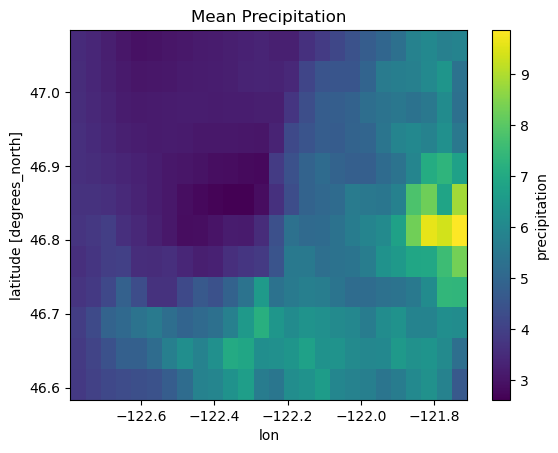

In [46]:
# Plot the mean precipitation to check it out
climate_mean = check_da.mean(dim="time")
climate_mean.plot()

# Add title
plt.title("Mean Precipitation")
plt.show()

In [47]:
# Check the min and max values of the mean precipitation
print(float(climate_mean.min()), float(climate_mean.max()))

2.611323833465576 9.863235473632812


In [48]:
# Check the shape of the cropped data array
climate_da_cropped.shape

(1826, 12, 26)

#### Function for downloading all maca data cropped precip

In [49]:
# Create function to get all climate data
def get_maca_cropped_precip(
    model,
    scenario,
    date_range,
    watershed_gdf,
    climate_dir,
    site_name = "Nisqually",
):
    """
    Function to open a remote MACA daily precipitation dataset for one time chunk,
    convert longitude from 0-360 to -180-180, crop to the watershed
    bounding box, load the cropped daily subset into memory, and save
    it locally as a NetCDF file.

    Args:
    model (str): MACA climate model name, e.g. "CCSM4".
    scenario (str): Scenario name, e.g. "historical", "rcp45", or "rcp85".
    date_range (str): Time chunk string, e.g. "1975_1979" or "2041_2045".
    watershed_gdf (geopandas.GeoDataFrame): Watershed boundary used for cropping.
    climate_dir (str): Directory where the cropped NetCDF file will be saved.
    site_name (str): Name of the study site for use in the output filename. Defaults to "Nisqually".

    Returns
    str: Path to the saved cropped NetCDF file.
    """

    # MACA ensemble convention
    ensemble = "r6i1p1" if model == "CCSM4" else "r1i1p1"

    # Build filename differently for historical vs future scenarios
    if scenario == "historical":
        remote_filename = (
            f"macav2metdata_pr_{model}_{ensemble}_historical_{date_range}_CONUS_daily.nc"
        )
    else:
        remote_filename = (
            f"macav2metdata_pr_{model}_{ensemble}_{scenario}_{date_range}_CONUS_daily.nc"
        )

    # Build remote URL
    climate_url = (
        "http://thredds.northwestknowledge.net:8080/thredds/dodsC"
        f"/MACAV2/{model}/{remote_filename}"
    )

    # Build local output path
    out_path = os.path.join(
        climate_dir,
        f"maca_{model}_{scenario}_{site_name}_{date_range}_cropped.nc"
    )

    # Skip if already exists
    if os.path.exists(out_path):
        print(f"Already exists: {out_path}")
        return out_path

    # Print message about opening remote dataset
    print(f"Opening remote dataset for {scenario} {date_range}...")

    # Open remote dataset
    ds = xr.open_dataset(climate_url)

    # Grab precipitation variable
    climate_da = ds["pr"] if "pr" in ds.data_vars else ds["precipitation"]

    # Convert longitude from 0-360 to -180-180 and sort
    climate_da = climate_da.assign_coords(
        lon=(((climate_da.lon + 180) % 360) - 180).data
    ).sortby("lon")

    # Watershed bounds in EPSG:4326 to match MACA coordinates
    watershed_4326 = watershed_gdf.to_crs("EPSG:4326")
    minx, miny, maxx, maxy = watershed_4326.total_bounds

    # Crop to bounding box
    climate_da_cropped = climate_da.sel(
        lon=slice(minx, maxx),
        lat=slice(miny, maxy)
    )

    # Load cropped subset into memory before saving
    climate_da_cropped = climate_da_cropped.load()

    # Quick sanity check on first day
    test = climate_da_cropped.isel(time=0)
    print("First-day cropped min/max:", float(test.min()), float(test.max()))

    # Save cropped daily data
    climate_da_cropped.to_netcdf(out_path)

    # Close remote dataset
    ds.close()

    print(f"Saved: {out_path}")
    return out_path

In [50]:
# Make sure function works by running it for one time chunk
test_path = get_maca_cropped_precip(
    model="CCSM4",
    scenario="rcp45",
    date_range="2046_2050",
    watershed_gdf=nisqually_gdf,
    climate_dir=climate_dir,
    site_name="Nisqually"
)

# Check the output path
print(test_path)

Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_rcp45_Nisqually_2046_2050_cropped.nc
C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_rcp45_Nisqually_2046_2050_cropped.nc


In [51]:
# Define historical date range for looping
historical_ranges = [
    "1975_1979",
    "1980_1984",
    "1985_1989",
    "1990_1994",
    "1995_1999",
    "2000_2004",
    "2005_2005",
]

# Define future date range for looping
future_ranges = [
    "2041_2045",
    "2046_2050",
    "2051_2055",
    "2056_2060",
    "2061_2065",
    "2066_2070",
]

In [52]:
# Create loop for all historical and future time chunks
saved_files = []

# Loop through historical ranges
for tr in historical_ranges:
    saved_files.append(
        get_maca_cropped_precip(
            model="CCSM4",
            scenario="historical",
            date_range=tr,
            watershed_gdf=nisqually_gdf,
            climate_dir=climate_dir,
            site_name="Nisqually",
        )
    )

# Loop through future ranges
for tr in future_ranges:
    saved_files.append(
        get_maca_cropped_precip(
            model="CCSM4",
            scenario="rcp45",
            date_range=tr,
            watershed_gdf=nisqually_gdf,
            climate_dir=climate_dir,
            site_name="Nisqually",
        )
    )

# Check the list of saved files
saved_files

Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1975_1979_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1980_1984_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1985_1989_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1990_1994_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\climate\maca_CCSM4_historical_Nisqually_1995_1999_cropped.nc
Already exists: C:\Users\nymve\Documents\education\earth-data-analytic

['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1975_1979_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1980_1984_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1985_1989_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1990_1994_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1995_1999_cropped.nc',
 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\sur

### NRCS Soil data download

Path: "C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\soils\gSSURGO_WA.zip"

In [53]:
# Path to the downloaded zip file
soils_zip_path = os.path.join(soils_dir, "gSSURGO_WA.zip")

# Extracted directory path
soils_extract_dir = os.path.join(soils_dir, "extracted")
os.makedirs(soils_extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(soils_zip_path, 'r') as zip_ref:
    zip_ref.extractall(soils_extract_dir)

# Path to GeoPackage (after unzip)
soils_gpkg_path = os.path.join(soils_extract_dir, "gSSURGO_WA.gdb")

In [54]:
# Make sure it exists
soils_gdf = gpd.read_file(soils_gpkg_path)

c:\Users\nymve\miniconda3\envs\earth-analytics-python\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'gSSURGO_WA.gdb': 'chaashto' (default), 'chconsistence', 'chdesgnsuffix', 'chfrags', 'chorizon', 'chpores', 'chstruct', 'chstructgrp', 'chtext', 'chtexture', 'chtexturegrp', 'chtexturemod', 'chunified', 'cocanopycover', 'cocropyld', 'codiagfeatures', 'coecoclass', 'coeplants', 'coerosionacc', 'coforprod', 'coforprodo', 'cogeomordesc', 'cohydriccriteria', 'comonth', 'component', 'copm', 'copmgrp', 'copwindbreak', 'corestrictions', 'cosoilmoist', 'cosoiltemp', 'cosurffrags', 'cosurfmorphgc', 'cosurfmorphhpp', 'cosurfmorphmr', 'cosurfmorphss', 'cotaxfmmin', 'cotaxmoistcl', 'cotext', 'cotreestomng', 'cotxfmother', 'distinterpmd', 'distlegendmd', 'distmd', 'featdesc', 'laoverlap', 'legend', 'legendtext', 'mapunit', 'month', 'muaggatt', 'muaoverlap', 'mucropyld', 'mutext', 'sacatalog', 'sdvalgorithm', 'sdvattribute', 'sdvfolder', 'sdvfolderattribute', 'm

In [55]:
# Check the map unit attributes layer
map_unit_attributes = gpd.read_file(soils_gpkg_path, layer="muaggatt")

# Check the first few rows of the map unit attributes
map_unit_attributes.head()

# Check the columns in the map unit attributes
map_unit_attributes.columns

Index(['musym', 'muname', 'mustatus', 'slopegraddcp', 'slopegradwta',
       'brockdepmin', 'wtdepannmin', 'wtdepaprjunmin', 'flodfreqdcd',
       'flodfreqmax', 'pondfreqprs', 'aws025wta', 'aws050wta', 'aws0100wta',
       'aws0150wta', 'drclassdcd', 'drclasswettest', 'hydgrpdcd', 'iccdcd',
       'iccdcdpct', 'niccdcd', 'niccdcdpct', 'engdwobdcd', 'engdwbdcd',
       'engdwbll', 'engdwbml', 'engstafdcd', 'engstafll', 'engstafml',
       'engsldcd', 'engsldcp', 'englrsdcd', 'engcmssdcd', 'engcmssmp',
       'urbrecptdcd', 'urbrecptwta', 'forpehrtdcp', 'hydclprs', 'awmmfpwwta',
       'mukey'],
      dtype='object')

In [56]:
# Read the map unit aggregate attributes table
map_unit_attributes = gpd.read_file(soils_gpkg_path, layer="muaggatt")
map_unit_attributes.columns = map_unit_attributes.columns.str.lower()

# Read the soils polygon layer
soils = gpd.read_file(soils_gpkg_path, layer="MUPOLYGON")
soils.columns = soils.columns.str.lower()

# Keep only the columns needed for this step
map_unit_attributes_subset = map_unit_attributes[["mukey", "hydgrpdcd"]].dropna()

# Join hydrologic group code to soil polygons
soils_gdf = soils.merge(map_unit_attributes_subset, on="mukey", how="left")

# Simplify hydrologic group values like "A/D" to a single group
def simplify_hydgrp(val):
    if pd.isna(val):
        return None
    return val.split("/")[-1]

# Create a cleaned hydrologic group field
soils_gdf["hydgrp"] = soils_gdf["hydgrpdcd"].apply(simplify_hydgrp)

# Quick checks
print(soils_gdf[["mukey", "hydgrpdcd", "hydgrp"]].head())
print(soils_gdf["hydgrp"].value_counts(dropna=False))

c:\Users\nymve\miniconda3\envs\earth-analytics-python\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


     mukey hydgrpdcd hydgrp
0  1451383       C/D      D
1  1483187         A      A
2  1151905       NaN   None
3  1151909         D      D
4  1451951         D      D
hydgrp
B       224938
C       135653
D        90097
A        70831
None     29157
Name: count, dtype: int64


In [57]:
# Check the CRS of the soils geodataframe
# Keep 5070 for analysis, but reproject to 4326 for plotting
soils_gdf.crs

<Projected CRS: EPSG:5070>
Name: NAD83 / Conus Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - CONUS onshore - Alabama; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming.
- bounds: (-124.79, 24.41, -66.91, 49.38)
Coordinate Operation:
- name: Conus Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Axes: >

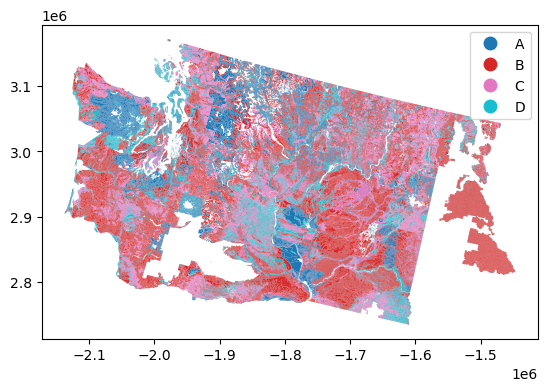

In [58]:
# Check out whole map of hydrologic soil groups
soils_gdf.plot(column="hydgrp", legend=True)

In [59]:
# Check out the columns in the soils geodataframe
print(soils_gdf.columns)

Index(['areasymbol', 'spatialver', 'musym', 'mukey', 'shape_length',
       'shape_area', 'geometry', 'hydgrpdcd', 'hydgrp'],
      dtype='object')


In [60]:
# Make sure in same CRS for clipping and plotting
soil_gdf_5070 = soils_gdf.to_crs("EPSG:5070")
nisqually_gdf_5070 = nisqually_gdf.to_crs("EPSG:5070")

In [61]:
# Clip the soil data to the watershed boundary
nisqually_soil_clip = gpd.clip(soil_gdf_5070, nisqually_gdf_5070)

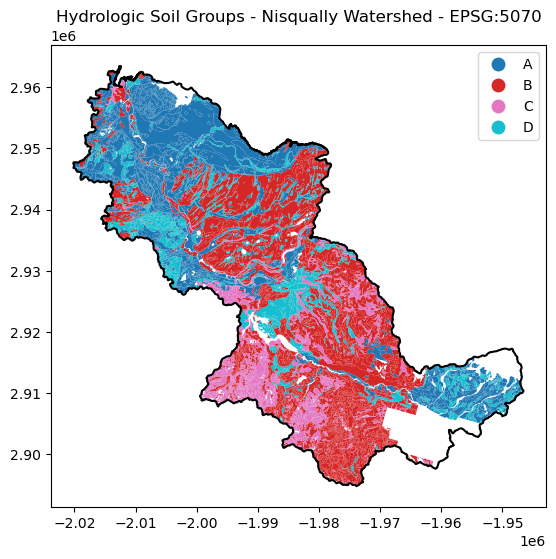

In [62]:
# Plot the clipped soil data
fig, ax = plt.subplots(figsize=(8,6))

# Plot the soil data with the hydrologic group column and a legend
nisqually_soil_clip.plot(
    column="hydgrp",
    ax=ax,
    legend=True
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="black")

# Add title
plt.title("Hydrologic Soil Groups - Nisqually Watershed - EPSG:5070")
plt.show()

In [63]:
# Check the hydrologic group values in the clipped soil data
nisqually_soil_clip["hydgrp"].value_counts(dropna=False)

hydgrp
B       2083
A       1630
D       1537
C        865
None     500
Name: count, dtype: int64

In [64]:
# create a clean modeling version
nisqually_soil_clean = nisqually_soil_clip.dropna(subset=["hydgrp"]).copy()

In [65]:
# Create soil score mapping based on hydrologic group, where A=0.1, B=0.4, C=0.7, D=1.0
soil_score_map = {
    "A": 0.0,
    "B": 0.37,
    "C": 0.78,
    "D": 1.0
}

# Add soil score column to the cleaned soil geodataframe
nisqually_soil_clean["soil_score"] = nisqually_soil_clean["hydgrp"].map(soil_score_map)

# Make sure there are no missing values in the soil score column
nisqually_soil_clean["soil_score"].isna().sum()  

np.int64(0)

In [66]:
# Check the first few rows of the cleaned soil geodataframe
nisqually_soil_polygons = zip(
    nisqually_soil_clean.geometry.values,
    nisqually_soil_clean["soil_score"].values
)

# Rasterize the soil polygons to create a soil score raster
nisqually_soil_raster = grid.rasterize(nisqually_soil_polygons, fill=np.nan)

In [67]:
# Create path for soil raster file
soil_raster_path = os.path.join(soils_dir, "nisqually_soil_score_5070.tif")

# Save the soil score raster to a GeoTIFF file
grid.to_raster(nisqually_soil_raster, soil_raster_path)

# Print the path to the saved soil raster
print("Saved soil raster to:", soil_raster_path)

Saved soil raster to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\soils\nisqually_soil_score_5070.tif


In [68]:
# Open the saved soil raster to check it out
nisqually_soil_da = rxr.open_rasterio(soil_raster_path, masked=True).squeeze()

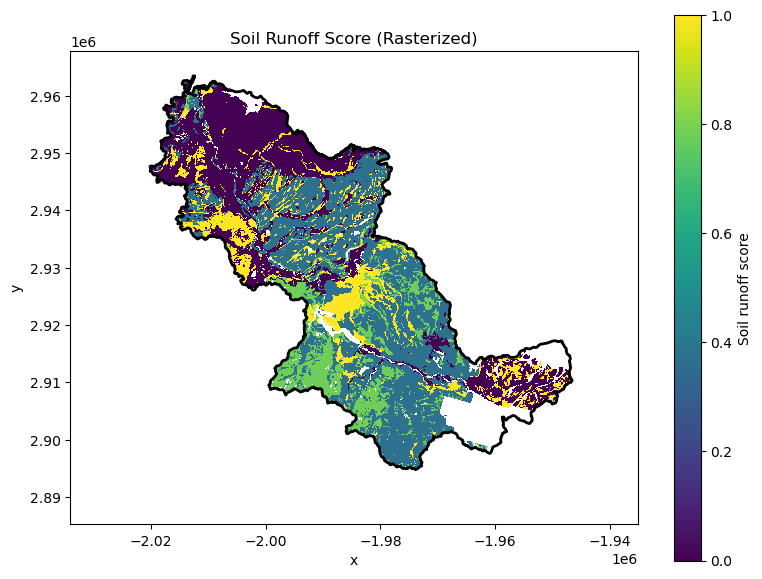

In [69]:
# Plot the soil score raster with the watershed boundary on top
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the soil score raster with a colormap and colorbar
nisqually_soil_da.plot(
    ax=ax,
    cmap="viridis",
    cbar_kwargs={"label": "Soil runoff score"} # Label for the colorbar
)

# Add watershed boundary on top with white edges
nisqually_gdf_5070.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2
)

# Add title
ax.set_title("Soil Runoff Score (Rasterized)")
plt.tight_layout()
plt.show()

## Processing & Analysis

#### SRTM Analysis Slope and Flow Accumulation

In [70]:
# Reproject the SRTM DEM to 5070 to calculate slope 
nisqually_rpj = nisqually_srtm_da.rio.reproject("EPSG:5070")

# Create a copy of the data array to modify for saving
save_da = nisqually_rpj.copy()

# Remove any existing _FillValue attribute and encoding to avoid issues when writing the raster
save_da.attrs.pop("_FillValue", None)

# Remove any existing _FillValue from encoding and set the nodata value to -9999
save_da.encoding.pop("_FillValue", None)
save_da = save_da.astype("float32").fillna(-9999)

# Write the nodata value to the raster metadata
save_da = save_da.rio.write_nodata(-9999)

# Create the path for the new raster file
dem_5070_path = os.path.join(topography_dir, "nisqually_dem_5070.tif")

# Save the raster as float32 with nodata value of -9999
save_da.rio.to_raster(dem_5070_path, dtype="float32")

In [71]:
# Open the reprojected DEM to check it out
dem_5070 = rxr.open_rasterio(dem_5070_path, masked=True).squeeze()

In [72]:
# Calculate slope
nisqually_slope = xrspatial.slope(dem_5070)

In [73]:
slope_5070_path = os.path.join(topography_dir, "nisqually_slope_5070.tif")

save_da = nisqually_slope.copy()
save_da.attrs.pop("_FillValue", None)
save_da.encoding.pop("_FillValue", None)
save_da = save_da.astype("float32").fillna(-9999)
save_da = save_da.rio.write_nodata(-9999)

save_da.rio.to_raster(slope_5070_path, dtype="float32")

In [74]:
def reproject_4326(input_path, output_path=None, dst_crs="EPSG:4326"):
    """
    Reproject a raster to a new CRS and save it to a new file for plotting.

    Args:
        input_path (str): Path to the input raster file.
        output_path (str): Path to the output raster file. If None, saves with "_4326" suffix.
        dst_crs (str): Target CRS. Default is "EPSG:4326".

    Returns:
        str: Path to the saved reprojected raster file.
    """

    # Open raster
    da = rxr.open_rasterio(input_path, masked=True).squeeze()

    # Reproject
    da_reprojected = da.rio.reproject(dst_crs)

    # Create output path if not provided
    if output_path is None:
        base, ext = os.path.splitext(input_path)
        base = base.replace("_5070", "")
        output_path = f"{base}_4326{ext}"

    # Clean + standardize before saving
    save_da = da_reprojected.copy()
    save_da.attrs.pop("_FillValue", None)
    save_da.encoding.pop("_FillValue", None)
    save_da = save_da.astype("float32")
    save_da = save_da.fillna(-9999)
    save_da = save_da.rio.write_nodata(-9999)

    # Save
    save_da.rio.to_raster(output_path, dtype="float32")

    print(f"Reprojected raster saved to: {output_path}")
    return output_path

In [75]:
# Reproject slope to 4326 for plotting
nisqually_slope_4326_path = reproject_4326(slope_5070_path)

# Open the reprojected slope raster to check it out
nisqually_slope_4326 = rxr.open_rasterio(nisqually_slope_4326_path, masked=True).squeeze()

Reprojected raster saved to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_slope_4326.tif


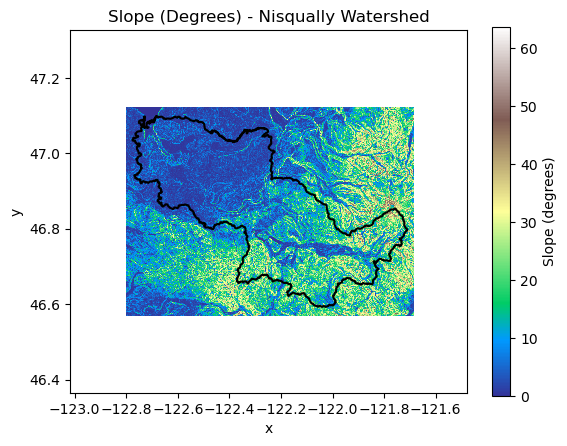

In [76]:
# Plot slope with watershed boundary
fig, ax = plt.subplots()

# Plot slope with a terrain colormap and colorbar with label
nisqually_slope_4326.plot(
    ax=ax,
    cmap='terrain',
    cbar_kwargs={'label': 'Slope (degrees)'}
)

# Add title
ax.set_title("Slope (Degrees) - Nisqually Watershed")

# Plot watershed boundary on top
nisqually_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# Show the plot
plt.show()

#### Calculate Flow Accumulation

In [77]:
# Read the DEM raster using pysheds
grid = Grid.from_raster(dem_5070_path)
dem = grid.read_raster(dem_5070_path)

In [78]:
# Condition DEM to fill depressions and calculate flow direction
# Fill pits in the DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in the DEM
flood_dem = grid.fill_depressions(pit_filled_dem)

# Resolve flats in the DEM
inflated_dem = grid.resolve_flats(flood_dem)


##### fdir is like a map of arrows, which cell each cell flows into

In [79]:
# Determmine D8 flow direction from DEM
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

# Compute flow directions 
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

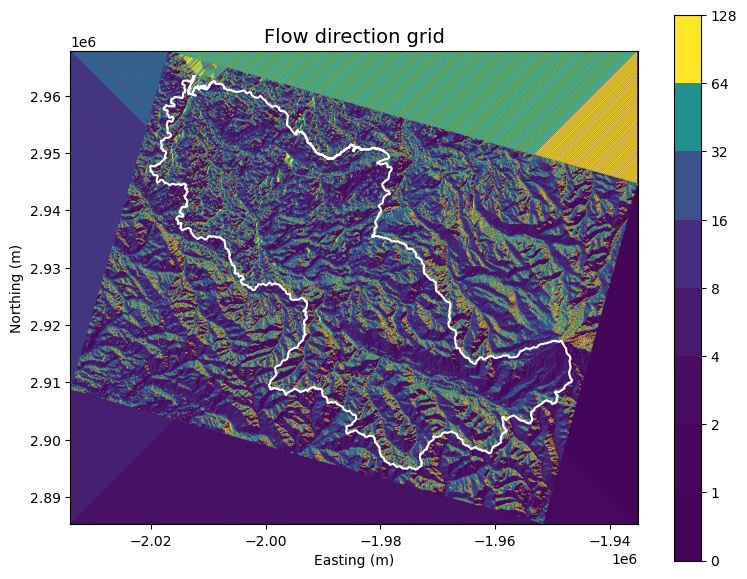

In [80]:
# Replace 0 values with NaN for better visualization
fdir_plot = np.where(fdir == 0, np.nan, fdir)

# Plot flow direction with watershed boundary on top
fig, ax = plt.subplots(figsize=(8,6))

# Plot flow direction with a colormap and colorbar with label
im = ax.imshow(
    fdir_plot,
    extent=grid.extent,
    cmap='viridis',
    zorder=2 # Set zorder to plot below the watershed boundary
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="white")

# Add colorbar with ticks corresponding to flow direction values
boundaries = [0] + sorted(list(dirmap))
plt.colorbar(im, boundaries=boundaries, values=sorted(dirmap))

# Add title and labels
ax.set_title('Flow direction grid', size=14)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.grid(zorder=-1) # Add gridlines behind the plot

plt.tight_layout()
plt.show()

In [81]:
# Calcuate flow accumulation
acc = grid.accumulation(fdir, dirmap=dirmap)

In [82]:
# Save the flow accumulation raster
flow_acc_path = os.path.join(topography_dir, "nisqually_flow_acc_5070.tif")
grid.to_raster(acc, flow_acc_path)

# Show the path to the saved flow accumulation raster
print("Flow accumulation raster saved to:", flow_acc_path)

Flow accumulation raster saved to: C:\Users\nymve\Documents\education\earth-data-analytics\spring-2026-data\surface-runoff-susceptibility-model\topography\nisqually_flow_acc_5070.tif


C:\Users\nymve\AppData\Local\Temp\ipykernel_19636\3925235238.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("cubehelix").copy()


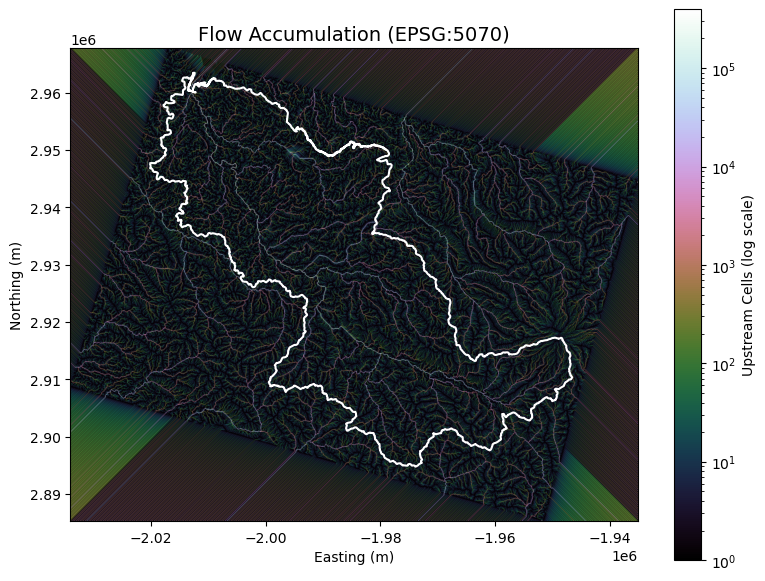

In [83]:
# Open saved 5070 flow accumulation raster
nisqually_flow_acc = rxr.open_rasterio(flow_acc_path, masked=True).squeeze()

# Mask zeros for log scale
acc_plot = np.where(nisqually_flow_acc <= 0, np.nan, nisqually_flow_acc)

# Colormap
cmap = cm.get_cmap("cubehelix").copy()
cmap.set_bad("white")

# Bounds for imshow need order: left, right, bottom, top
left, bottom, right, top = nisqually_flow_acc.rio.bounds()

# Plot flow accumulation with log scale
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_alpha(0)
ax.grid(zorder=0)

im = ax.imshow(
    acc_plot,
    extent=(left, right, bottom, top),
    cmap=cmap,
    norm=colors.LogNorm(vmin=1, vmax=np.nanmax(acc_plot)),
    interpolation="bilinear",
    zorder=2
)

# Add watershed boundary on top
nisqually_gdf_5070.boundary.plot(ax=ax, edgecolor="white")

plt.colorbar(im, ax=ax, label="Upstream Cells (log scale)")
ax.set_title("Flow Accumulation (EPSG:5070)", size=14)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

#### Process Climate Data - Subset years for mean precipitation and calculate Rx1day 

### Mean Precip over 30 years

In [84]:
# Historical files only
hist_files = sorted([
    str(f) for f in saved_files
    if "maca_CCSM4_historical_Nisqually" in Path(f).name
])

# Future files only
fut_files = sorted([
    str(f) for f in saved_files
    if "maca_CCSM4_rcp45_Nisqually" in Path(f).name
])

# Quick check of the files
print(len(hist_files), len(fut_files))
print(hist_files[:2])
print(fut_files[:2])

# Open the historical and future datasets as xarray multi-file datasets
ds_hist = xr.open_mfdataset(hist_files, combine="by_coords")
ds_fut = xr.open_mfdataset(fut_files, combine="by_coords")

7 6
['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1975_1979_cropped.nc', 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_historical_Nisqually_1980_1984_cropped.nc']
['C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_rcp45_Nisqually_2041_2045_cropped.nc', 'C:\\Users\\nymve\\Documents\\education\\earth-data-analytics\\spring-2026-data\\surface-runoff-susceptibility-model\\climate\\maca_CCSM4_rcp45_Nisqually_2046_2050_cropped.nc']


In [85]:
# Check the data variables in each dataset to see if it's "pr" or "precipitation"
pr_hist = ds_hist["pr"] if "pr" in ds_hist.data_vars else ds_hist["precipitation"]
pr_fut  = ds_fut["pr"] if "pr" in ds_fut.data_vars else ds_fut["precipitation"]

In [86]:
# Subset to years 1976 
pr_hist = pr_hist.sel(time=slice("1976-01-01", "2005-12-31"))

In [87]:
print(pr_hist.time.min().values, pr_hist.time.max().values)
print(len(pr_hist.time))

1976-01-01T00:00:00.000000000 2005-12-31T00:00:00.000000000
10958


In [89]:
def wet_season_mean_raster(da):
    """
    Calculate mean daily precipitation during the wet season (DJF).

    Args:
        da (xarray.DataArray): Daily precipitation with time dimension

    Returns:
        xarray.DataArray: Mean DJF precipitation raster (mm/day)
    """
    da_wet = da.sel(time=da["time.season"] == "DJF")
    return da_wet.mean(dim="time")

In [90]:
pr_hist_wet_mean = wet_season_mean_raster(pr_hist)

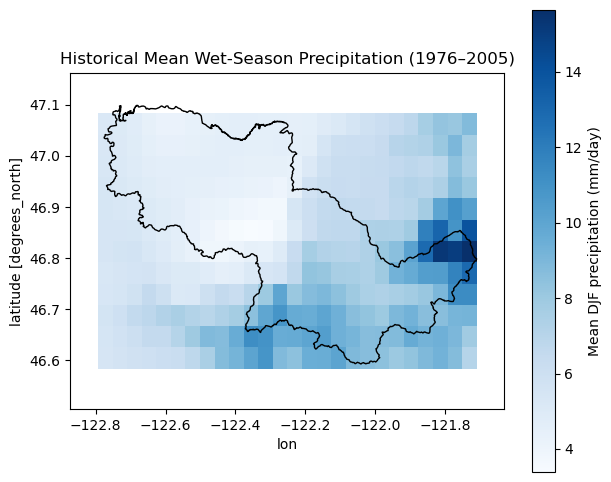

In [95]:
fig, ax = plt.subplots(figsize=(7, 6))

pr_hist_wet_mean.plot(
    ax=ax,
    cmap="Blues",
    cbar_kwargs={"label": "Mean DJF precipitation (mm/day)"}
)

nisqually_4326 = nisqually_gdf.to_crs("EPSG:4326")
nisqually_4326.boundary.plot(ax=ax, color="black", linewidth=1)

# Add visual buffer (degrees)
buffer = 0.1

ax.set_xlim(
    float(pr_hist_wet_mean.lon.min()) - buffer,
    float(pr_hist_wet_mean.lon.max()) + buffer
)

ax.set_ylim(
    float(pr_hist_wet_mean.lat.min()) - buffer,
    float(pr_hist_wet_mean.lat.max()) + buffer
)

ax.set_title("Historical Mean Wet-Season Precipitation (1976–2005)")

plt.show()